In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

print("✅ Librerías cargadas")

✅ Librerías cargadas


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\leFreeh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\leFreeh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
df = pd.read_csv("../data/dataset_combinado.csv")

print(f"Total filas: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
df.head(3)

Total filas: 44898
Columnas: ['title', 'text', 'subject', 'date', 'label', 'text_length']


,title,text,subject,date,label,text_length
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0,361
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0,495
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0,379


In [3]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def limpiar_texto(texto):
    # 1. Convertir a string por si hay NaN
    texto = str(texto)
    
    # 2. Minúsculas
    texto = texto.lower()
    
    # 3. Eliminar URLs
    texto = re.sub(r'http\S+|www\S+', '', texto)
    
    # 4. Eliminar menciones y caracteres especiales
    texto = re.sub(r'[^a-z\s]', '', texto)
    
    # 5. Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    # 6. Eliminar stopwords y aplicar stemming
    palabras = texto.split()
    palabras = [stemmer.stem(p) for p in palabras if p not in stop_words]
    
    return " ".join(palabras)

print("✅ Función de limpieza definida")

✅ Función de limpieza definida


In [4]:
print("⏳ Limpiando textos... (puede tardar 1-2 minutos)")

df["title_clean"] = df["title"].apply(limpiar_texto)
df["text_clean"] = df["text"].apply(limpiar_texto)

# Columna combinada título + texto (la que usaremos para entrenar)
df["content"] = df["title_clean"] + " " + df["text_clean"]

print("✅ Limpieza completada")
df[["title", "title_clean", "text_clean", "content", "label"]].head(3)

⏳ Limpiando textos... (puede tardar 1-2 minutos)
✅ Limpieza completada


,title,title_clean,text_clean,content,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,break gop chairman grassley enough demand trum...,donald trump white hous chao tri cover russia ...,break gop chairman grassley enough demand trum...,0
1,Failed GOP Candidates Remembered In Hilarious...,fail gop candid rememb hilari mock eulog video,donald trump presumpt gop nomine time rememb c...,fail gop candid rememb hilari mock eulog video...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,mike penc new dc neighbor hilari troll homopho...,mike penc huge homophob support exgay convers ...,mike penc new dc neighbor hilari troll homopho...,0


In [5]:
idx = 0  # Cambia este índice para ver distintos ejemplos

print("📰 TEXTO ORIGINAL:")
print(df["text"].iloc[idx][:300])
print("\n🧹 TEXTO LIMPIO:")
print(df["text_clean"].iloc[idx][:300])

📰 TEXTO ORIGINAL:
Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of this. To them, it s  fake news,  or a  hoax.  However, the facts bear things out differently, and it s

🧹 TEXTO LIMPIO:
donald trump white hous chao tri cover russia problem mount hour refus acknowledg problem surround fake news hoax howev fact bear thing differ seem crack congression public leadershipchuck grassley riowa head senat judiciari committe fed demand donald trump jr former trump campaign manag paul manafo


In [6]:
# Textos que quedaron vacíos después de limpiar
vacios = df[df["content"].str.strip() == ""]
print(f"Textos vacíos tras limpieza: {len(vacios)}")

# Eliminarlos si los hay
df = df[df["content"].str.strip() != ""].reset_index(drop=True)

print(f"Dataset final: {len(df)} filas")
print(f"Reales: {df[df['label']==1].shape[0]} | Falsas: {df[df['label']==0].shape[0]}")

Textos vacíos tras limpieza: 9
Dataset final: 44889 filas
Reales: 21417 | Falsas: 23472


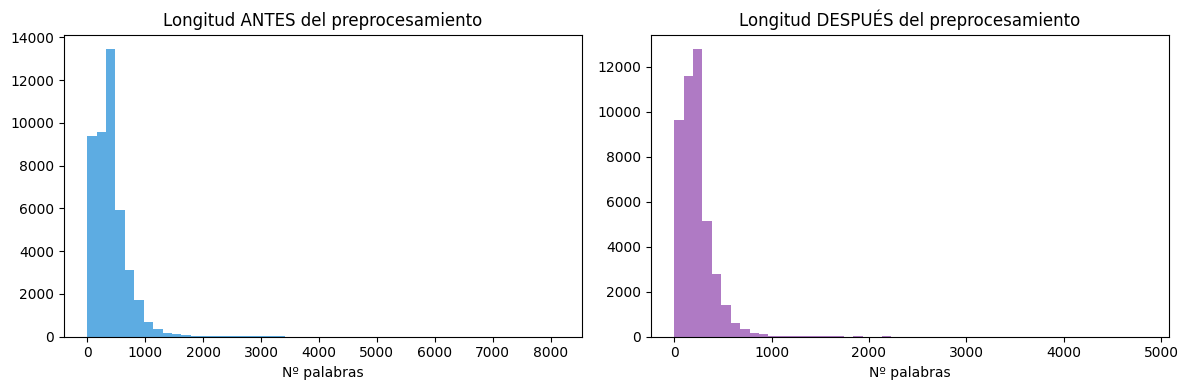

Media palabras original: 405
Media palabras limpio:   229


In [7]:
df["len_original"] = df["text"].apply(lambda x: len(str(x).split()))
df["len_limpio"] = df["text_clean"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["len_original"], bins=50, color="#3498db", alpha=0.8)
axes[0].set_title("Longitud ANTES del preprocesamiento")
axes[0].set_xlabel("Nº palabras")

axes[1].hist(df["len_limpio"], bins=50, color="#9b59b6", alpha=0.8)
axes[1].set_title("Longitud DESPUÉS del preprocesamiento")
axes[1].set_xlabel("Nº palabras")

plt.tight_layout()
plt.savefig("../outputs/longitud_antes_despues.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Media palabras original: {df['len_original'].mean():.0f}")
print(f"Media palabras limpio:   {df['len_limpio'].mean():.0f}")

In [8]:
df_final = df[["title", "text", "subject", "label", "content"]].copy()
df_final.to_csv("../data/dataset_preprocesado.csv", index=False)

print("✅ Guardado en /data/dataset_preprocesado.csv")
print(f"Columnas: {df_final.columns.tolist()}")
print(f"Shape: {df_final.shape}")

✅ Guardado en /data/dataset_preprocesado.csv
Columnas: ['title', 'text', 'subject', 'label', 'content']
Shape: (44889, 5)
